## Roughness scaling: correction factor & composite channel equations

_CF predictions, equivalent-roughness formulas (Lotter, Cox, Horton–Einstein, Felkel, …), and channel-equation comparisons._


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import os as _os
import sys
import shutil
import itertools as it
import contextlib
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler
import statsmodels.formula.api as smf
import json
from scipy.stats import gmean
import pandas as pd

sys.path.append("/Users/octaviacrompton/Projects/roughness-scale/swof_code")


import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

In [2]:
# ── Figure registry (src/figure_registry.py) ──────────────────────────────────
import sys as _sys
_sys.path.insert(0, "/Users/octaviacrompton/Projects/roughness-scale/src")
import figure_registry as _fig_reg

# Expose convenience names so all figure-saving cells work unchanged
_fig_dirs              = _fig_reg._fig_dirs
update_figure_registry = _fig_reg.update_figure_registry

# Note: call _fig_reg.configure(out_dir) once out_dir is set (see data-load cell)

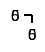

In [3]:
my_modules = ['plot_SWOF', "read_SWOF", "write_SWOF", 
              "plot_config", "topo", "source_functions_1p3"]

for mod in my_modules:
    if mod in sys.modules: 
        del sys.modules[mod] 

from plot_SWOF import *
from read_SWOF import *
from plot_config import *
from topo import *
from write_SWOF import *
from source_functions_1p3 import *


In [4]:
project_dir = "/Users/octaviacrompton/Dropbox/FullCSWOF/Tests/"
cases = [d for d in os.listdir(project_dir) if 
            ('DS_Store' not in d) and ('figures' not in d)]


In [5]:

# out_dir must match what was used in roughness_scale-load-compute
out_dir   = os.path.join(project_dir, 'runaround_smooth')
slim_path = os.path.join(out_dir, 'summary_slim.pkl')

summary = pd.read_pickle(slim_path)
print(f'Loaded summary_slim: shape = {summary.shape}')
print('Columns:', sorted(summary.columns.tolist()))

# initialise figure registry for this session
_fig_reg.configure(out_dir, notebook_name='roughness_scale-cf-channel_eqs.ipynb')

Loaded summary_slim: shape = (1260, 332)
Columns: ['$p t_r$', '<Sf>', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_T0', '<Sf>_T0_hyb', '<Sf>_T1', '<Sf>_T2', '<Sf>_Ubar2_np2', '<Sf>_cross_nU', '<Sf>_direct', '<Sf>_direct_minus_exp2', '<Sf>_direct_wet', '<Sf>_exp2', '<Sf>_hyb_Up2', '<Sf>_hyb_base', '<Sf>_hyb_cross', '<Sf>_hyb_np2', '<Sf>_hyb_num_sum', '<Sf>_hybrid_quad', '<Sf>_nbar2_Ubar2', '<Sf>_nbar2_Up2', '<Sf>_nd_T0', '<Sf>_nd_T1', '<Sf>_nd_T2', '<Sf>_nd_sumK2', '<Sf>_series2', '<U dU/dx>', '<U>', '<U>/<h>', '<U><dU/dx>', '<U>^2/<Up^2>', '<U>_CF', '<Ua>', '<Uh>', '<Up dUp/dx>', '<Up hp>', '<Up2>', '<dU/dx>', '<dh/dx>', '<dhp/dx>', '<eta ups>', '<eta2>', '<h>', '<h>_CF', '<h^2/3>', '<ha>', '<hp2>', '<n2>', '<n2><h>^-4/3', '<n>', '<n>2', '<n><U>', '<nU>', '<na>', '<np Up>', '<np hp>', '<np2>', '<q>_direct', '<q>_hform', '<q>_uform', '<r eta>', '<r ups>', '<r2>', '<ups2>', 'B_bc_NF', 'B_bc_init', 'Bbound', 'C', 'CPU_time', 'Cd', 'Cd_misc', 'Choice_dt_specific_points', 'Choice_points', 'F

In [6]:
# ── Variable naming / display labels ──────────────────────────────────────────
# Shared labels, colour maps, and helpers live in src/labels.py
import sys as _sys
_sys.path.insert(0, "/Users/octaviacrompton/Projects/roughness-scale/src")
from labels import (
    updates, rename, renameit,
    VEG_COLORS, VEG_LABELS,
    FS_LABEL, FS_TITLE, FS_TICK, FS_LEG,
    VAR_CMAPS,
    format_name as _format_name_raw,
)

# Wrap format_name so callers don't need to pass `names` explicitly
def format_name(fld, updates=updates):
    return _format_name_raw(fld, names, updates=updates)

summary['LB_std'] = [l.std() for l in summary.LB_dist]

# ── Toggle: set USE_HYDRO = True to make 'effect_ratio' use hydrograph-based n_e
USE_HYDRO = False
if USE_HYDRO:
    summary['effect']       = summary['effect_hydro']
    summary['effect_ratio'] = summary['effect_ratio_hydro']


## Correction factor

Two methods estimate spatially-averaged velocity $\langle U \rangle$ and depth $\langle h \rangle$ from the roughness field alone (no simulation output), letting us predict the effective Manning's $n_e = \langle h \rangle^{2/3} S_0^{1/2} / \langle U \rangle$.

**Correction factor** (`<U>_CF`, `<h>_CF`) — applies the point-scale kinematic-wave solution at every cell using the *full* slope length $l$ as the upslope distance, then spatially averages. This isolates the cross-slope (lateral) roughness heterogeneity while ignoring each cell's actual position along the slope.

$$\langle U \rangle_\text{CF} = \tfrac{5}{7} \left\langle \left[ \tfrac{1}{n}(q_0 l)^{2/3} S_0^{1/2} \right]^{3/5} \right\rangle \qquad \langle h \rangle_\text{CF} = \tfrac{5}{8} \left\langle \left( q_0\, l\, n\, S_0^{-1/2} \right)^{3/5} \right\rangle$$

**Slope-integrated** (`<Ua>`, `<ha>`) — integrates the kinematic-wave formula along each slope column using the *correct* upslope distance $x$, accounting for flow accumulation, then row-averages and normalises by $l$.

$$\langle U_a \rangle = \frac{1}{l} \left\langle \int_0^l \left[ \frac{(q_0 x)^{2/3}}{n(x)} S_0^{1/2} \right]^{3/5} dx \right\rangle \qquad \langle h_a \rangle = \frac{1}{l} \left\langle \int_0^l \left( q_0\, x\; n(x)\, S_0^{-1/2} \right)^{3/5} dx \right\rangle$$

The ratio $n_e / \langle n \rangle$ (columns `ne_CF` / `ne_a`) is the main diagnostic; values $< 1$ indicate that spatial organisation *reduces* bulk resistance below the arithmetic mean.

Registry updated → ../figures/runaround_smooth/figure_registry.txt  [SI1]


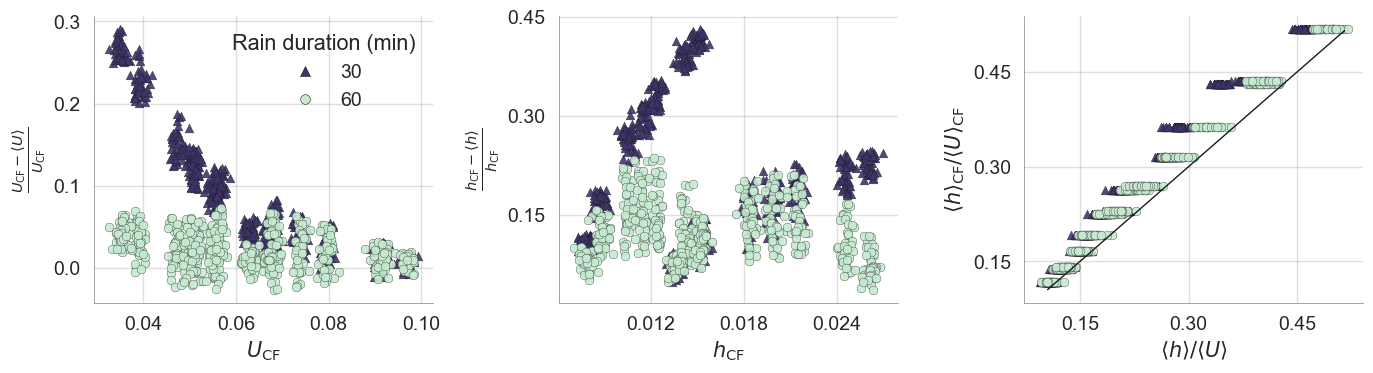

In [7]:
# fixed colors for the right-panel method comparison (independent of color_by)
COLOR_CF  = '#e6550d'   # orange  – correction factor
COLOR_INT = '#3182bd'   # blue    – integrate

def plot_CF_errors(df, color_by=None, tr_max=60, figsize=(14, 4),
                   color_cf=COLOR_CF, color_int=COLOR_INT,
                   fs_label=FS_LABEL + 3, fs_tick=FS_TICK + 2, fs_leg=FS_LEG + 2,
                   jitter=0.015):
    """
    Three-panel correction-factor diagnostic plot.

    Panels 1 & 2: relative U and h errors vs CF values, colored by `color_by`.
    Panel  3:     h/U identity — correction factor only, colored by `color_by`.

    Parameters
    ----------
    df        : DataFrame containing the run summary (e.g. `summary`)
    color_by  : column to use for coloring all three panels
    tr_max    : upper limit on `tr` for subsetting (inclusive)
    figsize   : figure size tuple
    color_cf  : (unused, kept for API compat)
    color_int : (unused, kept for API compat)
    jitter    : std-dev of Gaussian x-jitter (as fraction of x range)
    """
    from matplotlib.lines import Line2D
    from matplotlib.ticker import MaxNLocator

    _marker_pool = ['^', 'o', 's', 'D', 'P', 'X', 'v', '<', '>']

    sub = df.query("tr <= @tr_max").copy()

    # ── auto-detect color_by (same logic as scatter cell) ────────────────────
    if color_by is None:
        _vt = sub['veg_type'].unique()
        color_by = 'aniso' if set(_vt) == {'blob'} else 'veg_type'

    # ── build color + marker scheme ──────────────────────────────────────────
    def _build_color_scheme(data, col):
        if col not in data.columns:
            raise ValueError(f"Column '{col}' not found. Available: {list(data.columns)}")
        if col == 'veg_type':
            cats_ord  = [k for k in VEG_COLORS if k in data[col].unique()]
            cats_ord += [v for v in data[col].dropna().unique() if v not in cats_ord]
            cat_labels = [VEG_LABELS.get(c, c) for c in cats_ord]
            color_list = [VEG_COLORS.get(c, '#888888') for c in cats_ord]
            codes = np.array([cats_ord.index(v) if v in cats_ord else -1
                              for v in data[col]], dtype=int)
            title = 'vegetation'
        elif col == 'aniso':
            _aniso_name = {v: ('gradient-aligned' if v < 0 else
                               'isotropic'        if v == 1 else
                               'contour-aligned')
                           for v in sorted(data[col].dropna().unique())}
            _label_order = [l for l in ['gradient-aligned', 'isotropic', 'contour-aligned']
                            if l in _aniso_name.values()]
            _explicit_colors = {
                'gradient-aligned': '#2166ac',
                'isotropic':        '#a6d96a',
                'contour-aligned':  '#1a9641',
            }
            cat_labels = _label_order
            color_list = [_explicit_colors[l] for l in cat_labels]
            _label_to_idx = {l: i for i, l in enumerate(cat_labels)}
            codes = np.array([_label_to_idx.get(_aniso_name.get(v, ''), -1)
                              for v in data[col]], dtype=int)
            title = 'orientation'
        else:
            raw = pd.to_numeric(data[col], errors='coerce')
            if raw.notna().mean() > 0.9:
                uniq = np.array(sorted(raw.dropna().unique()))
                codes = np.array([np.searchsorted(uniq, v) if not np.isnan(v) else -1
                                  for v in raw], dtype=int)
                cat_labels = [f"{v:g}" for v in uniq]
                cmap_fn = plt.get_cmap('mako')
                color_list = [cmap_fn(t) for t in np.linspace(0.25, 0.95, max(len(uniq), 2))]
            else:
                cats_ord = sorted(data[col].dropna().unique())
                codes = np.array([cats_ord.index(v) if v in cats_ord else -1
                                  for v in data[col]], dtype=int)
                cat_labels = [str(c) for c in cats_ord]
                cmap_fn = plt.get_cmap('tab10')
                color_list = [cmap_fn(i / max(len(cats_ord)-1, 1)) for i in range(len(cats_ord))]
            title = col
        marker_list = [_marker_pool[i % len(_marker_pool)] for i in range(len(cat_labels))]
        # Force legend title for rain duration
        legend_title = 'Rain duration (min)' if col == 'tr' else title
        legend_handles = [
            Line2D([0], [0], marker=marker_list[i], color='none',
                   markerfacecolor=color_list[i],
                   markeredgecolor='k', markeredgewidth=0.4, markersize=7,
                   label=cat_labels[i])
            for i in range(len(cat_labels))
        ]
        return codes, cat_labels, color_list, marker_list, legend_handles, legend_title

    codes, cat_labels, colors, markers, leg_handles, leg_title = _build_color_scheme(sub, color_by)

    rng = np.random.default_rng(42)

    def _scatter(ax, x, y):
        x, y = np.asarray(x, float), np.asarray(y, float)
        xrange = np.nanmax(x) - np.nanmin(x)
        mask = np.isfinite(x) & np.isfinite(y) & (codes >= 0)
        for i in range(len(cat_labels)):
            sel = mask & (codes == i)
            if np.any(sel):
                xj = x[sel] + rng.normal(0, jitter * xrange, sel.sum())
                ax.scatter(xj, y[sel], s=40, alpha=0.9,
                           marker=markers[i],
                           color=colors[i], edgecolors='k', linewidths=0.25)

    # ── figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # Panel 1 – U error vs U_CF
    _scatter(axes[0],
             sub['<U>_CF'],
             (sub['<U>_CF'] - sub['<U>']) / sub['<U>_CF'])
    axes[0].set_xlabel(r"$U_{\rm CF}$", fontsize=fs_label)
    axes[0].set_ylabel(r"$\frac{U_{\rm CF}-\langle U\rangle}{U_{\rm CF}}$", fontsize=fs_label)
    axes[0].tick_params(labelsize=fs_tick)
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(handles=leg_handles, frameon=False, title='Rain duration (min)', loc='best',
                   fontsize=fs_leg)

    # Panel 2 – h error vs h_CF
    _scatter(axes[1],
             sub['<h>_CF'],
             (sub['<h>_CF'] - sub['<h>']) / sub['<h>_CF'])
    axes[1].set_xlabel(r"$h_{\rm CF}$", fontsize=fs_label)
    axes[1].set_ylabel(r"$\frac{h_{\rm CF}-\langle h\rangle}{h_{\rm CF}}$", fontsize=fs_label)
    axes[1].tick_params(labelsize=fs_tick)
    axes[1].grid(True, alpha=0.25)

    # Panel 3 – h/U identity (correction factor only, colored by same scheme)
    hU = sub['<h>'] / sub['<U>']
    axes[2].plot([hU.min(), hU.max()], [hU.min(), hU.max()], lw=1, color='k')
    _scatter(axes[2],
             hU,
             sub['<h>_CF'] / sub['<U>_CF'])
    axes[2].set_xlabel(r"$\langle h\rangle/\langle U\rangle$", fontsize=fs_label)
    axes[2].set_ylabel(r"$\langle h\rangle_{\rm CF}/\langle U\rangle_{\rm CF}$", fontsize=fs_label)
    axes[2].tick_params(labelsize=fs_tick)
    axes[2].grid(True, alpha=0.25)

    for ax in axes:
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    plt.tight_layout()
    return fig


# ── call ──────────────────────────────────────────────────────────────────────
COLOR_BY = 'tr'   # None = auto ('aniso' if only blobs, else 'veg_type'); or set explicitly: 'sigma', 'fV', 'tr', ...
fig = plot_CF_errors(summary, color_by=COLOR_BY)


# ── save as SI figure ─────────────────────────────────────────────────────────

_fig_dir, _, _ = _fig_dirs()

_si1_name = 'SI1_CF_errors_3panel.png'

fig.savefig(_os.path.join(_fig_dir, _si1_name), dpi=300, bbox_inches='tight')

update_figure_registry(
    'SI1', _si1_name,
    description=(
        'Three-panel correction-factor diagnostic.\n'
        f'Panels 1 & 2: relative U and h errors vs CF values, coloured by {COLOR_BY}.\n'
        'Panel 3: h/U identity comparison (correction factor only).\n'
    ),
    concise=(
        f'CF diagnostic coloured by {COLOR_BY}: '
        'relative U and h errors vs CF values, plus h/U identity for correction factor.'
    ),
)

### Equivalent roughness predictions

All four methods use only the **roughness field** (no simulation output).  

The CF per-cell depth and velocity apply the point-scale kinematic-wave solution at every cell using the full slope length $l$, then spatially average:

$$\langle U \rangle_\text{CF} = \frac{5}{7} \left\langle \left[ \frac{1}{n} \left( q_0\, l \right)^{2/3} S_0^{1/2} \right]^{3/5} \right\rangle, \qquad \langle h \rangle_\text{CF} = \frac{5}{8} \left\langle \left( q_0\, l\, n\, S_0^{-1/2} \right)^{3/5} \right\rangle$$

where $q_0 = (p - K_s)/3.6\times10^5\,\mathrm{m\,s^{-1}}$.  
<!-- Equivalent roughness is back-calculated as $n_e = \langle h \rangle^{2/3} S_0^{1/2} / \langle U \rangle$. -->


| Method | Formula |
|--------|---------|
| **Leading term (CF input)** | $n_e/\langle n\rangle \approx S_0 \langle h\rangle^{4/3} / (\langle n\rangle^2 \langle U\rangle^2)$ |
| **2nd-order $T_0$ (CF input)** | $n_e/\langle n\rangle \approx 1 + \langle r_n^2\rangle + \langle r_U^2\rangle + 4\langle r_n r_U\rangle$, where $r_n = n'/\bar{n}$, $r_U = U_i'/\bar{U}$ |
| **Lotter (CF input)** | $n_e/\langle n\rangle = \langle h^{5/3}\rangle / (\langle n\rangle \langle h^{5/3}/n\rangle) \equiv 1$ |
| **Felkel** | $n_e/\langle n\rangle = 1 \langle n\rangle^{-1} (\langle 1/n\rangle)^{-1}$  |

**Why Lotter = 1 for CF inputs.** The CF depth is $h_i = (q_0 l n_i / S_0^{1/2})^{3/5}$, so raising to the $5/3$ power gives

$$h_i^{5/3} = \frac{q_0\, l}{S_0^{1/2}}\, n_i \equiv C\, n_i$$

where $C = q_0 l / S_0^{1/2}$ is the same for every cell. Therefore $\langle h^{5/3}\rangle = C\langle n\rangle$ and $h_i^{5/3}/n_i = C$ (a cell-independent constant), so $\langle h^{5/3}/n\rangle = C$. Substituting:

$$\frac{n_e}{\langle n\rangle} = \frac{C\langle n\rangle}{\langle n\rangle \cdot C} = 1$$

The Lotter formula is uninformative for any set of inputs in which $h^{5/3} \propto n$ — which is what the CF approximation enforces.

Coloring by: sigma  (|r| with leading-term residual = 0.725)
Top correlates: [('sigma', -0.725), ('p', -0.125), ('tr', -0.075), ('fV', -0.044)]


Registry updated → ../figures/runaround_smooth/figure_registry.txt  [fig5]


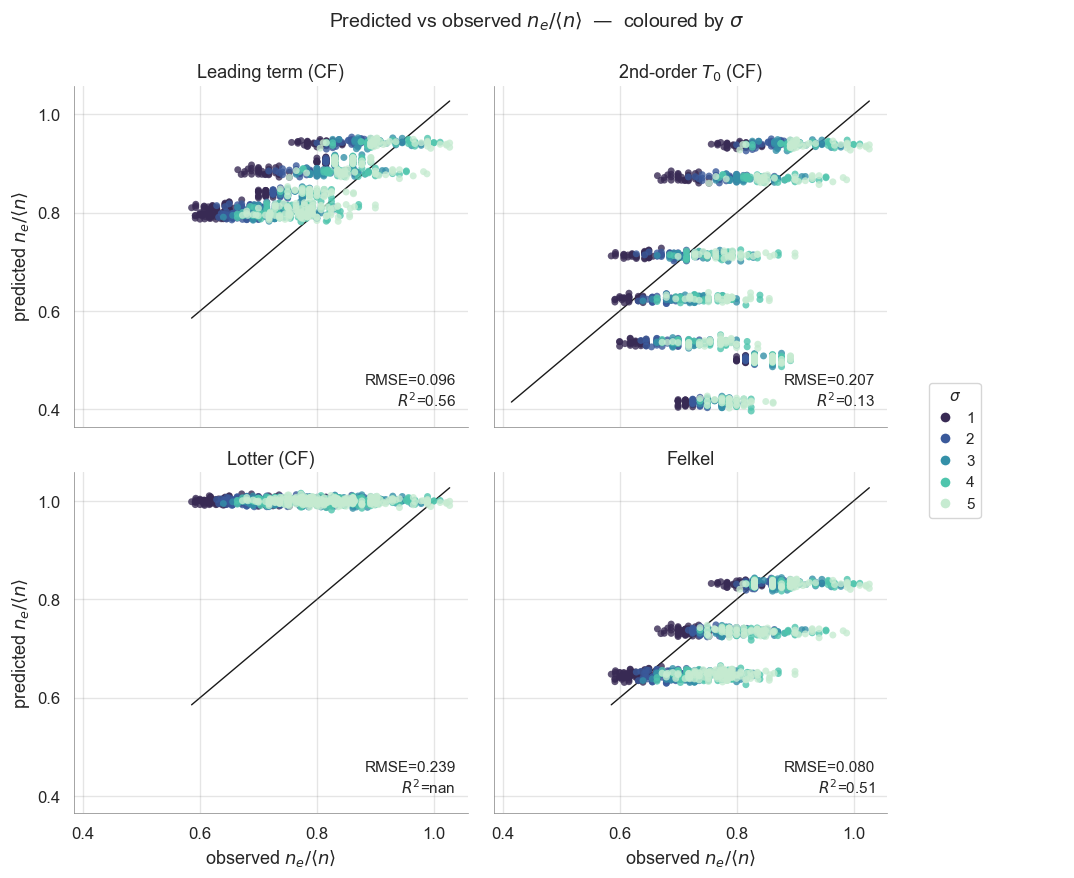

In [8]:

# ── Predicted vs observed effect ratio — CF-field methods + Felkel ─────────────
# All four methods use only the roughness field (no simulation output).
# Markers are coloured by the variable that explains the most variance in the
# Leading-term (CF) residuals (pred − obs).

from stats import rmse as _rmse, r2 as _r2, best_residual_correlate

# ── observed column ─────────────────────────────────────────────────────────────
er_obs_col = 'effect_ratio'

# ── compute CF-based equivalent roughness predictions ──────────────────────────
summary['er_lead_CF'] = (
    summary['<h>_CF']**(2/3) * summary['So']**0.5
    / (summary['<U>_CF'] * summary['<n>'])
)
summary['er_T0_CF'] = (
    1
    + summary['<r2>']
    + (9/25) * summary['<r2>']
    + 4 * (-3/5) * summary['<r2>']
)
summary['er_Lotter_CF'] = 1.0
summary['er_Felkel_CF'] = summary['n_exp8'] / summary['<n>']

# ── define 4-panel method list ──────────────────────────────────────────────────
methods = [
    ('er_lead_CF',   'Leading term (CF)'),
    ('er_T0_CF',     r'2nd-order $T_0$ (CF)'),
    ('er_Lotter_CF', 'Lotter (CF)'),
    ('er_Felkel_CF', 'Felkel'),
]

# ── find variable that best explains Leading-term residuals ─────────────────────
_obs_arr    = summary[er_obs_col].to_numpy(float)
_lead_pred  = summary['er_lead_CF'].to_numpy(float)
_m_lead     = np.isfinite(_obs_arr) & np.isfinite(_lead_pred)
_lead_resid = _lead_pred[_m_lead] - _obs_arr[_m_lead]

_candidates = best_residual_correlate(
    summary, _lead_resid, mask=_m_lead,
    sim_cols=['fV', 'sigma', 'p', 'tr', 'l', 'aniso'],
)
COLOR_BY_VAR_4P   = _candidates[0][0] if _candidates else 'fV'
_pretty           = {'fV': r'$f_V$', 'sigma': r'$\sigma$', 'aniso': 'anisotropy',
                     'p': r'$p$ (mm/h)', 'tr': r'$t_r$ (min)', 'l': r'$L$ (m)'}
COLOR_BY_LABEL_4P = _pretty.get(COLOR_BY_VAR_4P, COLOR_BY_VAR_4P)
_cmap_name_4p     = VAR_CMAPS.get(COLOR_BY_VAR_4P, 'viridis')
_cmap_4p_base     = plt.get_cmap(_cmap_name_4p)
_cmap_4p          = mpl.colors.LinearSegmentedColormap.from_list(
    f'trunc_{_cmap_name_4p}', _cmap_4p_base(np.linspace(0.2, 0.95, 256)))

if _candidates:
    print(f"Coloring by: {COLOR_BY_VAR_4P}  (|r| with leading-term residual = {abs(_candidates[0][1]):.3f})")
    print("Top correlates:", [(c, round(r, 3)) for c, r in _candidates[:4]])
else:
    print(f"Coloring by: {COLOR_BY_VAR_4P}  (no valid correlates found; using default)")

# ── build discrete colour levels ────────────────────────────────────────────────
_color_vals_raw = pd.to_numeric(summary[COLOR_BY_VAR_4P], errors='coerce')
_unique_vals    = sorted(_color_vals_raw.dropna().unique())
MAX_LEVELS_4P   = 6
if len(_unique_vals) > MAX_LEVELS_4P:
    _binned      = pd.qcut(_color_vals_raw, q=MAX_LEVELS_4P, duplicates='drop')
    _bin_levels  = _binned.cat.categories.tolist()
    _color_vals  = _binned.cat.codes.astype(float)
    _color_vals[_binned.isna()] = np.nan
    _color_levels = list(range(len(_bin_levels)))
    _level_label  = lambda i: f'[{_bin_levels[i].left:.3g}, {_bin_levels[i].right:.3g}]'
else:
    _color_vals   = _color_vals_raw.to_numpy(float)
    _color_levels = _unique_vals
    _level_label  = lambda v: f'{v}'

_norm_4p    = mpl.colors.Normalize(vmin=min(_color_levels), vmax=max(_color_levels))
_palette_4p = {cv: _cmap_4p(_norm_4p(cv)) for cv in _color_levels}

# ── 2×2 plot ────────────────────────────────────────────────────────────────────
from matplotlib.ticker import MaxNLocator

fs_lab, fs_tck, fs_leg = 13, 12, 11
fig2, axes2 = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
axes2_flat  = axes2.ravel()

for idx, (ax, (pred_col, title)) in enumerate(zip(axes2_flat, methods)):
    obs  = summary[er_obs_col].to_numpy(float)
    pred = (summary[pred_col].to_numpy(float)
            if pred_col in summary.columns else np.full(len(summary), np.nan))

    finite = np.isfinite(obs) & np.isfinite(pred)
    if finite.sum() == 0:
        ax.set_title(f"{title}\n(no data)", fontsize=fs_lab)
        continue

    lo = min(np.nanmin(obs[finite]), np.nanmin(pred[finite]))
    hi = max(np.nanmax(obs[finite]), np.nanmax(pred[finite]))
    ax.plot([lo, hi], [lo, hi], 'k-', lw=1, zorder=0)

    _rng = np.random.default_rng(42)
    for cv in _color_levels:
        sel = finite & (np.abs(_color_vals - cv) < 1e-9)
        if sel.sum() == 0:
            continue
        _jitter = _rng.normal(0, 0.005, sel.sum())
        ax.scatter(obs[sel], pred[sel] + _jitter,
                   color=_palette_4p[cv], marker='o',
                   s=25, alpha=0.80, edgecolors='none', zorder=3)

    rmse = _rmse(pred[finite], obs[finite])
    r2v  = _r2(pred[finite], obs[finite])
    ax.set_title(title, fontsize=fs_lab)
    ax.text(0.97, 0.05, f'RMSE={rmse:.3f}\n$R^2$={r2v:.2f}',
            transform=ax.transAxes, fontsize=fs_tck - 1,
            ha='right', va='bottom', zorder=5)
    ax.tick_params(labelsize=fs_tck)
    ax.grid(True, alpha=0.2)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    if idx >= 2:
        ax.set_xlabel(r"observed $n_e/\langle n\rangle$", fontsize=fs_lab)
    if idx % 2 == 0:
        ax.set_ylabel(r"predicted $n_e/\langle n\rangle$", fontsize=fs_lab)

    # ── collect per-method metrics for dynamic registry text ─────────────────
    if not hasattr(fig2, '_method_metrics'):
        fig2._method_metrics = {}
    fig2._method_metrics[pred_col] = dict(title=title, rmse=rmse, r2=r2v)

fig2.suptitle(r"Predicted vs observed $n_e/\langle n\rangle$"
              f"  —  coloured by {COLOR_BY_LABEL_4P}", fontsize=fs_lab + 1)
fig2.tight_layout(rect=[0, 0, 0.84, 1])

# ── legend ───────────────────────────────────────────────────────────────────────
leg_ax = fig2.add_axes([0.85, 0.12, 0.13, 0.74])
leg_ax.set_axis_off()
from matplotlib.lines import Line2D
_leg_handles = [Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=_palette_4p[cv], markersize=8, label=_level_label(cv))
                for cv in _color_levels]
leg_ax.legend(handles=_leg_handles, title=COLOR_BY_LABEL_4P, loc='center left',
              fontsize=fs_leg, title_fontsize=fs_leg, frameon=True, handlelength=1.2)

# ── save figure ──────────────────────────────────────────────────────────────────
_fig_dir, _, _ = _fig_dirs()
_fig5_name = 'fig5_pred_vs_obs_CF.png'
fig2.savefig(_os.path.join(_fig_dir, _fig5_name), dpi=300, bbox_inches='tight')

# ── build dynamic registry text from per-method metrics ──────────────────────
_mm = fig2._method_metrics
_interp_lines = []
for _pc, _ttl in methods:
    _m = _mm.get(_pc, {})
    _r2s = f"R²={_m['r2']:.2f}" if np.isfinite(_m.get('r2', np.nan)) else "R² undefined"
    _rms = f"RMSE={_m['rmse']:.3f}" if np.isfinite(_m.get('rmse', np.nan)) else ""
    _interp_lines.append(f"  - {_m.get('title', _pc)}: {_r2s}, {_rms}".rstrip(', '))

# Identify best method by R² (excluding NaN)
_valid = [(k, v) for k, v in _mm.items() if np.isfinite(v.get('r2', np.nan))]
if _valid:
    _best_key  = max(_valid, key=lambda x: x[1]['r2'])
    _worst_key = min(_valid, key=lambda x: x[1]['r2'])
    _best_title,  _best_r2  = _best_key[1]['title'],  _best_key[1]['r2']
    _worst_title, _worst_r2 = _worst_key[1]['title'], _worst_key[1]['r2']
    _concise_5 = (f"Predicted vs observed n_e/<n> for four CF methods, coloured by {COLOR_BY_VAR_4P}. "
                  f"{_best_title} performs best (R²={_best_r2:.2f}); "
                  f"{_worst_title} is weakest (R²={_worst_r2:.2f}).")
else:
    _concise_5 = f"Predicted vs observed n_e/<n> for four CF methods, coloured by {COLOR_BY_VAR_4P}."

update_figure_registry(
    'fig5', _fig5_name,
    'Predicted vs observed n_e/<n> for four CF-field methods (Leading term, T0, Lotter, Felkel).\n'
    f'Markers coloured by {COLOR_BY_VAR_4P} (highest |r| with leading-term residual).\n'
    'RMSE/R² annotated per panel.\n'
    '\n'
    'Per-method performance:\n' + '\n'.join(_interp_lines) + '\n'
    '\n'
    f'Residuals correlate most with {COLOR_BY_VAR_4P}; '
    f'dominant errors occur at extreme {COLOR_BY_VAR_4P} values.',
    concise=_concise_5)

plt.show()


## Effect ratio vs $f_V$, $\sigma$, and storm parameters


In [9]:
# ── Which variable best explains residuals in the CF predictions? ──────────────
# Uses the leading-term residual (pred - obs) as the response; correlates against
# input design parameters only (those printed by print_input_params(sim_list)).

_resid_col = 'er_lead_CF'   # focus on the most physically non-trivial method
_df_diag = summary.copy()
_df_diag['_rain_cm'] = _df_diag['p'].astype(float) * _df_diag['tr'].astype(float) / 60.0
_df_diag['_resid']   = _df_diag[_resid_col].astype(float) - _df_diag[er_obs_col].astype(float)

# --- candidate variables = input design parameters from sim_list (+ derived) ---
# Mimics print_input_params(sim_list): pd.DataFrame(sim_list).columns minus 'seed'.
# Falls back to hardcoded known design parameters if sim_list is not in scope.
try:
    _sim_cols = [c for c in pd.DataFrame(sim_list).columns if c != 'seed']
except NameError:
    _sim_cols = ['p', 'tr', 'l', 'So', 'fV', 'sigma', 'aniso', 'alpha_v', 'alpha_b', 'Ks_v']

_sim_cols_plus = _sim_cols + ['_rain_cm']   # add derived rainfall-depth column

_candidates = []
for c in _sim_cols_plus:
    if c not in _df_diag.columns:
        continue
    try:
        v = pd.to_numeric(_df_diag[c], errors='coerce')
        m = v.notna() & _df_diag['_resid'].notna()
        if m.sum() < 20 or v[m].std() < 1e-10:
            continue
        r = float(np.corrcoef(v[m], _df_diag['_resid'][m])[0, 1])
        if np.isfinite(r):
            _candidates.append((c, r))
    except Exception:
        pass

_candidates.sort(key=lambda x: abs(x[1]), reverse=True)
_top = _candidates[:15]

print(f"Top correlates with leading-term residual (pred − obs):\n")
print(f"{'Variable':<30}  {'r':>7}  {'R²':>7}")
print("-" * 48)
for c, r in _top:
    print(f"{c:<30}  {r:+.3f}  {r**2:.3f}")

# ── winner used by the plot below ─────────────────────────────────────────────
COLOR_BY_VAR   = _top[0][0]          # highest |r| with residual
_pretty = {'fV': r'$f_V$', 'sigma': r'$\sigma$', 'aniso': 'anisotropy',
           'p': r'$p$ (mm/h)', 'tr': r'$t_r$ (min)', 'l': r'$L$ (m)',
           '_rain_cm': r'$p\cdot t_r/60$ (cm)', 'alpha_v': r'$n_v$',
           'alpha_b': r'$n_b$', 'r_ratio': r'$n_b/n_v$',
           'So': r'$S_0$', 'Ks_v': r'$K_s$'}
COLOR_BY_LABEL = _pretty.get(COLOR_BY_VAR, COLOR_BY_VAR)
print(f"\n→ coloring next plot by: {COLOR_BY_VAR}  (r = {_top[0][1]:+.3f})")
COLOR_BY_CMAP = VAR_CMAPS.get(COLOR_BY_VAR, 'viridis')


Top correlates with leading-term residual (pred − obs):

Variable                              r       R²
------------------------------------------------
sigma                           -0.725  0.526
p                               -0.125  0.016
_rain_cm                        -0.117  0.014
tr                              -0.075  0.006
fV                              -0.044  0.002
aniso                           +0.001  0.000

→ coloring next plot by: sigma  (r = -0.725)


## Channel equation comparisons

All equations are compared as **absolute** $n_c$ vs $r_e$ (observed equivalent roughness)
and as **normalised** $n_c / \langle n \rangle$ vs $n_e / \langle n \rangle$.

### Equations included

| # | Method | Column | Formula | Tier |
|---|--------|--------|---------|------|
| 1 | Lotter (1933) | `nc_lotter` | $n_c = \bar{h}^{5/3} / \langle h_i^{5/3}/n_i \rangle$ | 1 |
| 2 | Pavlovskii (1931) | `nc_pavlovskii` | $n_c = \sqrt{\langle n_i^2 \rangle}$ | 1 |
| 3 | Horton–Einstein (1933) | `nc_horton` | $n_c = \langle n_i^{3/2} \rangle^{2/3}$ | 1 |
| 4 | Cox / arithmetic mean | `nc_arith` | $n_c = \langle n_i \rangle$ | 1 |
| 5 | Krishnamurthy–Christensen (1972) | `nc_KC` | $n_c = \exp\!\bigl(\langle h_i^{3/2} \ln n_i \rangle / \langle h_i^{3/2} \rangle\bigr)$ | 1 |
| 6 | Colebatch | `nc_colebatch` | $n_c = \bigl(\langle h_i n_i^{3/2} \rangle / \bar{h}\bigr)^{2/3}$ | 2 |
| 7 | Yen $R^{1/6}$ (2002) | `nc_yen16` | $n_c = \bar{h}^{1/6} \langle n_i / h_i^{1/6} \rangle$ | 2 |
| 8 | Yen $R^{1/3}$ / Shear Force I | `nc_yen13` | $n_c = \langle h_i^{1/3} n_i \rangle / \bar{h}^{1/3}$ | 2 |
| 9 | Felkel (1960) | `nc_felkel` | $n_c = 1 / \langle n_i^{-1} \rangle$ | 2 |

**Notes:**
- **Linear P-weighted** (Djajadi Expr. 9) reduces to the arithmetic mean $\langle n_i \rangle$ for
  uniform-width overland flow (all wetted perimeters equal), so it is identical to Cox here.
- **Dracos–Hardegger** is excluded: it requires an inter-subarea momentum-transfer coefficient
  that is not available from the SWOF scalar summary.
- Columns `nc_*` are computed in `roughness_scale-compute.ipynb`. If absent from
  `summary_slim.pkl`, the setup cell below aliases from legacy `n_exp*` columns where
  possible; methods with no fallback show a "rerun compute notebook" annotation.


In [ ]:
# ── Column availability: use nc_ if present, fallback to n_exp* legacy columns ──────────────
# Run roughness_scale-compute.ipynb to populate nc_* columns in summary_slim.pkl.
# Until then, the n_exp* columns provide identical values for n-field-only methods.

_NC_FALLBACKS = {
    'nc_lotter':     'n_exp3',   # Lotter: h^5/3 mean / h^5/3/n mean
    'nc_pavlovskii': 'n_exp2',   # Pavlovskii: sqrt(<n^2>)
    'nc_horton':     'n_exp1',   # Horton-Einstein: <n^1.5>^(2/3)
    'nc_arith':      'n_exp4',   # Cox / arithmetic mean
    'nc_felkel':     'n_exp8',   # Felkel: harmonic mean
    'nc_yen13':      'n_exp6',   # Yen R^(1/3) = Shear-force (Expr 6)
    # depth-dependent methods with no n_exp fallback:
    'nc_KC':         None,
    'nc_colebatch':  None,
    'nc_yen16':      None,
}

_missing_methods = []
for _col, _fb in _NC_FALLBACKS.items():
    if _col not in summary.columns:
        if _fb is not None and _fb in summary.columns:
            summary[_col] = summary[_fb]
            print(f'  alias  {_col:<20} <- {_fb}')
        else:
            _missing_methods.append(_col)
            print(f'  MISSING {_col:<19}  (rerun roughness_scale-compute.ipynb to populate)')

# ── Master method list: (column, short title, equation label, tier)
_METHODS = [
    ('nc_lotter',     'Lotter',                   r'$\bar{h}^{5/3}/\langle h^{5/3}/n\rangle$',                      1),
    ('nc_pavlovskii', 'Pavlovskii',                r'$\sqrt{\langle n^2\rangle}$',                                   1),
    ('nc_horton',     'Horton-Einstein',           r'$\langle n^{3/2}\rangle^{2/3}$',                                 1),
    ('nc_arith',      'Cox / arithmetic',          r'$\langle n\rangle$',                                             1),
    ('nc_KC',         'Krishnamurthy-Christensen', r'$\exp(\langle h^{3/2}\ln n\rangle/\langle h^{3/2}\rangle)$', 1),
    ('nc_colebatch',  'Colebatch',                 r'$(\langle h\,n^{3/2}\rangle/\bar{h})^{2/3}$',                 2),
    ('nc_yen16',      'Yen R^{1/6}',               r'$\bar{h}^{1/6}\langle n/h^{1/6}\rangle$',                      2),
    ('nc_yen13',      'Yen R^{1/3}',               r'$\langle h^{1/3}n\rangle/\bar{h}^{1/3}$',                      2),
    ('nc_felkel',     'Felkel',                    r'$1/\langle n^{-1}\rangle$',                                      2),
]

_n_avail = sum(col in summary.columns for col, *_ in _METHODS)
print(f'\nMethods available: {_n_avail}/{len(_METHODS)}')
if _missing_methods:
    print(f'Missing (need compute rerun): {_missing_methods}')


In [ ]:
# ── Find variable with highest mean |r| with residuals across all available expressions ────────
from stats import rmse as _rmse, r2 as _r2

_obs_col   = 'r_equiv'
_expr_cols = [col for col, *_ in _METHODS if col in summary.columns]

try:
    _sim_cols = [c for c in pd.DataFrame(sim_list).columns if c != 'seed']
except NameError:
    _sim_cols = ['p', 'tr', 'l', 'So', 'fV', 'sigma', 'aniso', 'alpha_v', 'alpha_b', 'Ks_v']

_hue_scores = {}
for c in _sim_cols:
    if c not in summary.columns:
        continue
    try:
        v = pd.to_numeric(summary[c], errors='coerce')
        rs = []
        for ec in _expr_cols:
            resid = summary[ec] - summary[_obs_col]
            m = v.notna() & resid.notna() & np.isfinite(resid)
            if m.sum() < 20 or v[m].std() < 1e-10:
                continue
            r = float(np.corrcoef(v[m], resid[m])[0, 1])
            if np.isfinite(r):
                rs.append(abs(r))
        if rs:
            _hue_scores[c] = np.mean(rs)
    except Exception:
        pass

_hue_var   = max(_hue_scores, key=_hue_scores.get) if _hue_scores else 'fV'
_hue_score = _hue_scores.get(_hue_var, 0)
print(f"Coloring by: {_hue_var!r}  (mean |r| across expressions = {_hue_score:.3f})")
print({k: f"{v:.3f}" for k, v in sorted(_hue_scores.items(), key=lambda x: -x[1])[:8]})

# ── discrete palette for the chosen variable ──────────────────────────────────
MAX_HUE = 6
_hv_raw    = pd.to_numeric(summary[_hue_var], errors='coerce')
_hv_unique = sorted(_hv_raw.dropna().unique())

if len(_hv_unique) > MAX_HUE:
    _hv_binned = pd.qcut(_hv_raw, q=MAX_HUE, duplicates='drop')
    _hv_levels = sorted(_hv_binned.dropna().unique(), key=lambda x: x.left)
    _hv_labels = [f'({b.left:.3g}, {b.right:.3g}]' for b in _hv_levels]
    _hv_codes  = pd.Categorical(_hv_binned, categories=_hv_levels).codes
    summary['_hue_group'] = [_hv_labels[c] if c >= 0 else np.nan for c in _hv_codes]
    _hue_order = _hv_labels
else:
    summary['_hue_group'] = _hv_raw.apply(lambda x: f'{x:g}' if np.isfinite(x) else np.nan)
    _hue_order = [f'{v:g}' for v in _hv_unique]

_cmap_base_ch = plt.get_cmap(VAR_CMAPS.get(_hue_var, 'viridis'))
_cmap_ch      = mpl.colors.LinearSegmentedColormap.from_list(
    'trunc', _cmap_base_ch(np.linspace(0.2, 0.95, 256)))
_hue_palette  = {lbl: _cmap_ch(i / max(len(_hue_order) - 1, 1))
                 for i, lbl in enumerate(_hue_order)}

_pretty_hue = {
    'fV': r'$f_V$', 'sigma': r'$\sigma$', 'aniso': 'anisotropy',
    'p': r'$p$ (mm/h)', 'tr': r'$t_r$ (min)', 'l': r'$L$ (m)',
    'So': r'$S_0$', 'Ks_v': r'$K_s$', 'alpha_v': r'$n_v$', 'alpha_b': r'$n_b$',
}
_hue_label = _pretty_hue.get(_hue_var, _hue_var)


In [ ]:
# ── Absolute comparison: observed r_e vs predicted n_c  (3x3 grid) ────────────────────────────
from matplotlib.lines import Line2D as _L2D
from matplotlib.ticker import MaxNLocator

_nrows, _ncols = 3, 3
_fs_t, _fs_l, _fs_k = FS_TITLE - 1, FS_LABEL - 1, FS_TICK - 1

fig_abs, axes_abs = plt.subplots(_nrows, _ncols, figsize=(13, 10), sharex=False, sharey=False)
axes_abs_flat = axes_abs.ravel()

_all_metrics = {}

for idx, (col, title, eq_label, tier) in enumerate(_METHODS):
    ax = axes_abs_flat[idx]

    if col not in summary.columns:
        ax.set_facecolor('#f5f5f5')
        ax.text(0.5, 0.5, f'{title}\n(run compute notebook)', transform=ax.transAxes,
                ha='center', va='center', fontsize=_fs_k, color='#888')
        ax.set_title(title, fontsize=_fs_t)
        _all_metrics[col] = dict(title=title, r2=np.nan, rmse=np.nan)
        continue

    obs  = summary['r_equiv'].to_numpy(float)
    pred = summary[col].to_numpy(float)
    finite = np.isfinite(obs) & np.isfinite(pred)

    lo = min(np.nanmin(obs[finite]), np.nanmin(pred[finite]))
    hi = max(np.nanmax(obs[finite]), np.nanmax(pred[finite]))
    ax.plot([lo, hi], [lo, hi], 'k-', lw=1, zorder=0)

    for lbl in _hue_order:
        grp = (summary['_hue_group'] == lbl).to_numpy()
        sel = finite & grp
        if sel.sum() == 0:
            continue
        ax.scatter(obs[sel], pred[sel], color=_hue_palette[lbl],
                   s=18, alpha=0.80, edgecolors='none', zorder=3)

    _r2v   = _r2(pred[finite], obs[finite])
    _rmsev = _rmse(pred[finite], obs[finite])
    _all_metrics[col] = dict(title=title, r2=_r2v, rmse=_rmsev)

    ax.text(0.97, 0.05, f'RMSE={_rmsev:.3f}\n$R^2$={_r2v:.2f}',
            transform=ax.transAxes, fontsize=_fs_k - 1,
            ha='right', va='bottom', zorder=5)
    ax.set_title(f'{title}\n{eq_label}', fontsize=_fs_t - 1)
    ax.tick_params(labelsize=_fs_k)
    ax.grid(True, alpha=0.2)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    row_i, col_i = divmod(idx, _ncols)
    if row_i == _nrows - 1:
        ax.set_xlabel(r'observed $r_e$', fontsize=_fs_l)
    if col_i == 0:
        ax.set_ylabel(r'predicted $n_c$', fontsize=_fs_l)

fig_abs.suptitle(
    r'Observed $r_e$ vs predicted $n_c$ — composite-channel equations'
    f'  (coloured by {_hue_label})',
    fontsize=FS_TITLE)
fig_abs.tight_layout(rect=[0, 0, 0.84, 1])

leg_ax_abs = fig_abs.add_axes([0.85, 0.12, 0.13, 0.74])
leg_ax_abs.set_axis_off()
_h_leg = [_L2D([0],[0], marker='o', color='w',
               markerfacecolor=_hue_palette[lbl], markersize=8, label=lbl)
          for lbl in _hue_order]
leg_ax_abs.legend(handles=_h_leg, title=_hue_label, loc='center left',
                  fontsize=FS_LEG, title_fontsize=FS_LEG, frameon=True)

plt.show()

# performance table
print(f"{'Method':<32}  {'R2':>6}  {'RMSE':>8}")
print('-' * 52)
for c_key, m in _all_metrics.items():
    _r2s = f"{m['r2']:.3f}"  if np.isfinite(m.get('r2',  np.nan)) else '  -  '
    _rms = f"{m['rmse']:.4f}" if np.isfinite(m.get('rmse', np.nan)) else '   -   '
    print(f"{m['title']:<32}  {_r2s:>6}  {_rms:>8}")


In [ ]:
# ── Normalised comparison: n_e/<n> (simulated) vs n_c/<n> (predicted)  (3x3) ─────────────────
# Isolates the heterogeneity-driven scaling independent of the mean roughness level.

_n_mean = summary['<n>'].to_numpy(float)

fig_norm, axes_norm = plt.subplots(_nrows, _ncols, figsize=(13, 10),
                                    sharex=False, sharey=False)
axes_norm_flat = axes_norm.ravel()

_norm_metrics = {}

for idx, (col, title, eq_label, tier) in enumerate(_METHODS):
    ax = axes_norm_flat[idx]

    if col not in summary.columns:
        ax.set_facecolor('#f5f5f5')
        ax.text(0.5, 0.5, f'{title}\n(run compute notebook)', transform=ax.transAxes,
                ha='center', va='center', fontsize=_fs_k, color='#888')
        ax.set_title(title, fontsize=_fs_t)
        continue

    obs_er  = summary['effect_ratio'].to_numpy(float)
    pred_nr = summary[col].to_numpy(float) / _n_mean
    finite  = np.isfinite(obs_er) & np.isfinite(pred_nr)

    lo = min(np.nanmin(obs_er[finite]), np.nanmin(pred_nr[finite]))
    hi = max(np.nanmax(obs_er[finite]), np.nanmax(pred_nr[finite]))
    ax.plot([lo, hi], [lo, hi], 'k-', lw=1, zorder=0)

    for lbl in _hue_order:
        grp = (summary['_hue_group'] == lbl).to_numpy()
        sel = finite & grp
        if sel.sum() == 0:
            continue
        ax.scatter(obs_er[sel], pred_nr[sel], color=_hue_palette[lbl],
                   s=18, alpha=0.80, edgecolors='none', zorder=3)

    _r2v   = _r2(pred_nr[finite], obs_er[finite])
    _rmsev = _rmse(pred_nr[finite], obs_er[finite])
    _norm_metrics[col] = dict(title=title, r2=_r2v, rmse=_rmsev)

    ax.text(0.97, 0.05, f'RMSE={_rmsev:.3f}\n$R^2$={_r2v:.2f}',
            transform=ax.transAxes, fontsize=_fs_k - 1,
            ha='right', va='bottom', zorder=5)
    ax.set_title(f'{title}\n{eq_label}', fontsize=_fs_t - 1)
    ax.tick_params(labelsize=_fs_k)
    ax.grid(True, alpha=0.2)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    row_i, col_i = divmod(idx, _ncols)
    if row_i == _nrows - 1:
        ax.set_xlabel(r'$n_e / \langle n \rangle$ (simulated)', fontsize=_fs_l)
    if col_i == 0:
        ax.set_ylabel(r'$n_c / \langle n \rangle$ (predicted)', fontsize=_fs_l)

fig_norm.suptitle(
    r'Normalised: $n_e/\langle n\rangle$ (simulated) vs $n_c/\langle n\rangle$ (predicted)'
    f'  (coloured by {_hue_label})',
    fontsize=FS_TITLE)
fig_norm.tight_layout(rect=[0, 0, 0.84, 1])

leg_ax_norm = fig_norm.add_axes([0.85, 0.12, 0.13, 0.74])
leg_ax_norm.set_axis_off()
leg_ax_norm.legend(handles=_h_leg, title=_hue_label, loc='center left',
                   fontsize=FS_LEG, title_fontsize=FS_LEG, frameon=True)
plt.show()


In [ ]:
# ── Relative bias histograms: (n_c / r_e) - 1 per method ────────────────────────────────────
# >0 means over-prediction; <0 means under-prediction.

_avail = [(col, title, eq_label, tier) for col, title, eq_label, tier in _METHODS
          if col in summary.columns]
_na = len(_avail)
_hcols = min(_na, 3)
_hrows = (_na + _hcols - 1) // _hcols

fig_hist, axes_hist = plt.subplots(_hrows, _hcols,
                                    figsize=(4.5 * _hcols, 3.5 * _hrows),
                                    sharex=True, sharey=False)
axes_hist_flat = np.array(axes_hist).ravel()

for i, (col, title, eq_label, tier) in enumerate(_avail):
    ax = axes_hist_flat[i]
    rel_bias = (summary[col] / summary['r_equiv']) - 1
    rel_bias = rel_bias.replace([np.inf, -np.inf], np.nan).dropna()
    ax.hist(rel_bias, bins=np.arange(-0.5, 0.55, 0.05),
            color='steelblue', edgecolor='white', lw=0.4)
    ax.axvline(0, c='k', lw=1.2)
    _med = float(rel_bias.median())
    ax.axvline(_med, c='firebrick', lw=1.2, ls='--')
    ax.set_title(f'{title}\nmedian={_med:+.3f}', fontsize=FS_TITLE - 2)
    ax.set_xlabel(r'$(n_c/r_e) - 1$', fontsize=FS_LABEL - 1)
    ax.tick_params(labelsize=FS_TICK - 1)

for j in range(_na, len(axes_hist_flat)):
    axes_hist_flat[j].set_visible(False)

fig_hist.suptitle(r'Relative bias $(n_c / r_e) - 1$ per composite-channel method',
                  fontsize=FS_TITLE)
fig_hist.tight_layout()
plt.show()


In [ ]:
# ── Save absolute comparison as SI2; save normalised + histogram to scratch ──────────────────
_fig_dir, _scratch_dir, _ = _fig_dirs()

_si2_name = 'SI2_channel_eqs_9panel.png'
fig_abs.savefig(_os.path.join(_fig_dir, _si2_name), dpi=300, bbox_inches='tight')

# save normalised and histogram to scratch (exploratory)
fig_norm.savefig(_os.path.join(_scratch_dir, 'scratch_channel_eqs_normalised.png'),
                 dpi=200, bbox_inches='tight')
fig_hist.savefig(_os.path.join(_scratch_dir, 'scratch_channel_eqs_bias_hist.png'),
                 dpi=200, bbox_inches='tight')

# dynamic registry text
_valid_m  = [(c, m) for c, m in _all_metrics.items() if np.isfinite(m.get('r2', np.nan))]
_best_m   = max(_valid_m, key=lambda x: x[1]['r2'])[1] if _valid_m else {}
_worst_m  = min(_valid_m, key=lambda x: x[1]['r2'])[1] if _valid_m else {}
_perf     = sorted(_valid_m, key=lambda x: -x[1]['r2'])
_p_lines  = [f"  - {m['title']}: R2={m['r2']:.2f}, RMSE={m['rmse']:.4f}" for _, m in _perf]

update_figure_registry(
    'SI2', _si2_name,
    description=(
        'Observed r_e vs predicted n_c for nine composite-channel equations '
        '(Lotter, Pavlovskii, Horton-Einstein, Cox, Krishnamurthy-Christensen, '
        'Colebatch, Yen R^1/6, Yen R^1/3, Felkel).\n'
        f'Coloured by {_hue_var}. Missing methods annotated for compute rerun.\n'
        '\nPer-method performance (sorted by R2):\n' + '\n'.join(_p_lines) + '\n'
        f'\nBest: {_best_m.get("title","?")} (R2={_best_m.get("r2",0):.2f}); '
        f'Worst: {_worst_m.get("title","?")} (R2={_worst_m.get("r2",0):.2f}).'
    ),
    concise=(
        f'Nine composite-channel equations vs observed r_e, coloured by {_hue_var}. '
        f'{_best_m.get("title","?")} performs best (R2={_best_m.get("r2",0):.2f}); '
        f'{_worst_m.get("title","?")} weakest.'
    ),
)
print(f'Saved  {_si2_name}  ->  {_fig_dir}')
